## Notebook 2 : Implémentez un modéle de scoring

In [67]:
from pathlib import Path

src = Path(r"C:\Users\domir\Documents\src")

print("Existe :", src.exists())
print("Dossier :", src.is_dir())

print("\nContenu de src :")
for f in src.iterdir():
    print("-", f.name)


Existe : True
Dossier : True

Contenu de src :
- feature_importance.py
- metrics.py
- mlflow_utils.py
- preprocessing.py
- train.py
- __init__.py
- __pycache__


In [68]:
pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [69]:
import sys
from pathlib import Path

# Ajouter le dossier parent de src
sys.path.insert(0, r"C:\Users\domir\Documents")

from src.preprocessing import (
    load_application_data,
    create_application_features,
    build_full_dataset,
    prepare_train_test_data,
    CreditScoringPreprocessor
)

print("✅ Import réussi")
print("📁 Module preprocessing chargé")


✅ Import réussi
📁 Module preprocessing chargé


## Chargons des Données

In [70]:
# Analyse de la variable cible
print("\n📈 Répartition de la variable cible (TARGET)")
print(train_df["TARGET"].value_counts())

default_rate = train_df["TARGET"].mean() * 100
print(f"\n📌 Pourcentage de clients en défaut : {default_rate:.2f}%")



📈 Répartition de la variable cible (TARGET)
TARGET
0    282686
1     24825
Name: count, dtype: int64

📌 Pourcentage de clients en défaut : 8.07%


In [82]:
import pandas as pd

# Chemins des fichiers
train_path = r"C:\Users\domir\Downloads\Projet 7 OPEN\Projet+Mise+en+prod+-+home-credit-default-risk\application_train.csv"
test_path = r"C:\Users\domir\Downloads\Projet 7 OPEN\Projet+Mise+en+prod+-+home-credit-default-risk\application_test.csv"

# Chargement des données brutes
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# Vérification
print("Train :", train_df.shape)
print("Test :", test_df.shape)

display(train_df.head())

Train : (307511, 122)
Test : (48744, 121)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## créer de nouvelles variables (feature engineering)

In [83]:
train_fe = create_application_features(train_df.copy())
test_fe = create_application_features(test_df.copy())

In [84]:
new_cols = [c for c in train_fe.columns if c not in train_df.columns]

print(f"📊 {len(new_cols)} nouvelles features créées :")

for col in new_cols:
    print("-", col)

📊 14 nouvelles features créées :
- CREDIT_INCOME_RATIO
- ANNUITY_INCOME_RATIO
- CREDIT_GOODS_RATIO
- INCOME_PER_PERSON
- ANNUITY_LENGTH
- AGE_YEARS
- EMPLOYED_YEARS
- EMPLOYED_TO_AGE_RATIO
- EXT_SOURCE_MEAN
- EXT_SOURCE_STD
- EXT_SOURCE_MIN
- EXT_SOURCE_MAX
- DOCUMENTS_COUNT
- CONTACTS_COUNT


In [86]:
# Statistiques descriptives des variables créées
train_fe[new_cols].describe()

,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_GOODS_RATIO,INCOME_PER_PERSON,ANNUITY_LENGTH,AGE_YEARS,EMPLOYED_YEARS,EMPLOYED_TO_AGE_RATIO,EXT_SOURCE_MEAN,EXT_SOURCE_STD,EXT_SOURCE_MIN,EXT_SOURCE_MAX,DOCUMENTS_COUNT,CONTACTS_COUNT
count,307511.000000,307499.000000,307233.000000,3.075090e+05,307499.000000,307511.000000,307511.000000,307511.000000,307339.000000,2.706020e+05,3.073390e+05,307339.000000,307511.000000,307511.000000
mean,3.957537,0.180928,1.122992,5.748225e+04,21.611295,43.936973,-174.835742,-2.871851,0.509251,1.512456e-01,3.995821e-01,0.615882,0.930155,3.355174
std,2.689696,0.094573,0.124044,6.585166e+04,7.823599,11.956133,387.056895,6.511765,0.149802,9.991074e-02,1.874246e-01,0.156130,0.344295,0.865288
min,0.004808,0.000224,0.150000,2.647059e+03,8.036227,20.517808,-1000.665753,-45.338009,0.000006,3.538459e-07,8.173617e-08,0.000006,0.000000,1.000000
25%,2.018659,0.114781,0.999999,3.375000e+04,15.614247,34.008219,0.791781,0.020981,0.413648,7.238552e-02,2.539628e-01,0.540654,1.000000,3.000000
50%,3.265042,0.162832,1.118798,4.950000e+04,19.999259,43.150685,3.323288,0.086318,0.524502,1.360209e-01,4.031671e-01,0.648470,1.000000,3.000000
75%,5.159857,0.229064,1.197998,6.750000e+04,27.099077,53.923288,7.561644,0.186063,0.622819,2.143878e-01,5.530128e-01,0.725276,1.000000,4.000000
max,84.733539,1.875892,5.999867,2.925000e+07,45.301400,69.120548,49.073973,0.718146,0.878903,6.519439e-01,8.789034e-01,0.962693,4.000000,6.000000


In [89]:
import matplotlib.pyplot as plt
from pathlib import Path

# Créer le dossier reports s'il n'existe pas
Path("reports").mkdir(exist_ok=True)

# Ajuster la mise en page et sauvegarder le graphique
plt.tight_layout()

plt.savefig(
    "reports/new_features_correlations.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

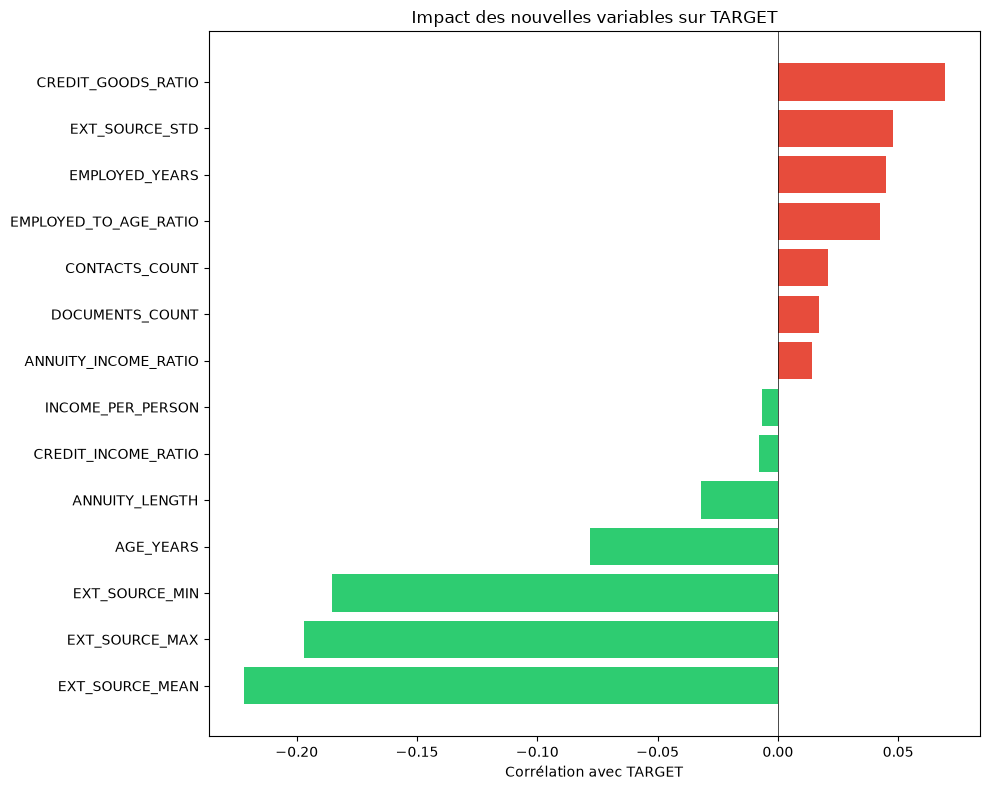

In [90]:
from pathlib import Path

# Corrélation des nouvelles variables avec TARGET
correlations = train_fe[new_cols + ['TARGET']].corr()['TARGET'].drop('TARGET').sort_values()

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in correlations.values]

ax.barh(range(len(correlations)), correlations.values, color=colors)
ax.set_yticks(range(len(correlations)))
ax.set_yticklabels(correlations.index)

ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Corrélation avec TARGET')
ax.set_title('Impact des nouvelles variables sur TARGET')

# Création du dossier reports
Path("reports").mkdir(exist_ok=True)

plt.tight_layout()
plt.savefig("reports/new_features_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

## Les Tables Auxiliaires

In [92]:
from pathlib import Path

# Chemin correct vers les données Home Credit
data_dir = Path(
    r"C:\Users\domir\Downloads\Projet 7 OPEN\Projet+Mise+en+prod+-+home-credit-default-risk"
)

# Vérification des fichiers
print("application_train.csv :", (data_dir / "application_train.csv").exists())
print("application_test.csv  :", (data_dir / "application_test.csv").exists())

application_train.csv : True
application_test.csv  : True


In [93]:
train_full, test_full = build_full_dataset(
    data_dir=data_dir,
    include_supplementary=True,
    sample_frac=0.1
)

print("\n📊 Dataset final")
print(f"Train : {train_full.shape}")
print(f"Test  : {test_full.shape}")
print(f"Nombre de variables : {train_full.shape[1] - 2}")

📊 Construction du dataset complet...
✅ Données chargées: train=(307511, 122), test=(48744, 121)
   ⚡ Échantillonnage: 10.0%
   🔧 Feature engineering application...
   📁 Agrégation bureau...
   📁 Agrégation previous_application...
   📁 Agrégation installments...
   📁 Agrégation POS_CASH...
   📁 Agrégation credit_card...
✅ Dataset construit: train=(30751, 246), test=(4874, 245)

📊 Dataset final
Train : (30751, 246)
Test  : (4874, 245)
Nombre de variables : 244


In [94]:
# Analyse des variables issues des tables auxiliaires
agg_cols = [
    col for col in train_full.columns
    if any(prefix in col for prefix in ['BUREAU_', 'PREV_', 'INST_', 'POS_', 'CC_'])
]

print("\n===== FEATURES AGRÉGÉES =====")
print(f"Nombre total de features agrégées : {len(agg_cols)}")

categories = {
    "BUREAU": "Historique des crédits",
    "PREV": "Demandes précédentes",
    "INST": "Paiements échelonnés",
    "POS": "Crédits en cours",
    "CC": "Cartes de crédit"
}

for prefix, description in categories.items():
    nb = len([col for col in agg_cols if col.startswith(f"{prefix}_")])
    print(f"{description:<25} : {nb} features")


===== FEATURES AGRÉGÉES =====
Nombre total de features agrégées : 116
Historique des crédits    : 41 features
Demandes précédentes      : 27 features
Paiements échelonnés      : 12 features
Crédits en cours          : 14 features
Cartes de crédit          : 16 features


## Pepiline de prétraitément 

In [95]:
# Créer et fitter le préprocesseur
preprocessor = CreditScoringPreprocessor(
    impute_strategy='median',
    scale=False,
    drop_high_nan=0.8  # Supprimer les colonnes avec >80% de NaN
)

# Fit sur train
X_train = preprocessor.fit_transform(train_full)
y_train = train_full['TARGET']

# Transform sur test
X_test = preprocessor.transform(test_full)

print(f"\n📊 Données prétraitées:")
print(f"   X_train: {X_train.shape}")
print(f"   X_test: {X_test.shape}")
print(f"   y_train: {y_train.shape}")

✅ Préprocesseur fitted: 243 features

📊 Données prétraitées:
   X_train: (30751, 243)
   X_test: (4874, 243)
   y_train: (30751,)


In [97]:
import numpy as np

# Contrôle des valeurs manquantes après transformation
missing_train = np.isnan(X_train).sum()
missing_test = np.isnan(X_test).sum()

pct_train = missing_train / X_train.size * 100
pct_test = missing_test / X_test.size * 100

print("\n===== CONTRÔLE DES VALEURS MANQUANTES =====")
print(f"Train : {missing_train} valeurs manquantes ({pct_train:.4f} %)")
print(f"Test  : {missing_test} valeurs manquantes ({pct_test:.4f} %)")


===== CONTRÔLE DES VALEURS MANQUANTES =====
Train : 0 valeurs manquantes (0.0000 %)
Test  : 0 valeurs manquantes (0.0000 %)


In [98]:
# Affichage des variables supprimées
nb_colonnes = len(preprocessor.columns_to_drop)

print("\n===== COLONNES SUPPRIMÉES =====")
print(f"Nombre total de colonnes supprimées : {nb_colonnes}")

for colonne in preprocessor.columns_to_drop[:10]:
    print(f"• {colonne}")

if nb_colonnes > 10:
    print(f"... {nb_colonnes - 10} colonnes supplémentaires non affichées")


===== COLONNES SUPPRIMÉES =====
Nombre total de colonnes supprimées : 3
• CC_AMT_PAYMENT_CURRENT_MEAN
• SK_ID_CURR
• TARGET


In [99]:
# Aperçu des variables conservées après prétraitement
print("\n===== FEATURES FINALES =====")
print(f"Nombre total de features : {len(preprocessor.feature_names)}")

print("\nPremières features :")
for i, feature in enumerate(preprocessor.feature_names[:20], start=1):
    print(f"{i}. {feature}")


===== FEATURES FINALES =====
Nombre total de features : 243

Premières features :
1. NAME_CONTRACT_TYPE
2. CODE_GENDER
3. FLAG_OWN_CAR
4. FLAG_OWN_REALTY
5. CNT_CHILDREN
6. AMT_INCOME_TOTAL
7. AMT_CREDIT
8. AMT_ANNUITY
9. AMT_GOODS_PRICE
10. NAME_TYPE_SUITE
11. NAME_INCOME_TYPE
12. NAME_EDUCATION_TYPE
13. NAME_FAMILY_STATUS
14. NAME_HOUSING_TYPE
15. REGION_POPULATION_RELATIVE
16. DAYS_BIRTH
17. DAYS_EMPLOYED
18. DAYS_REGISTRATION
19. DAYS_ID_PUBLISH
20. OWN_CAR_AGE


## sauvegardons le préprocesseur

In [101]:
from pathlib import Path

# Création du dossier models dans le dossier courant
output_dir = Path("models")
output_dir.mkdir(parents=True, exist_ok=True)

# Enregistrement du préprocesseur
save_path = output_dir / "preprocessor.joblib"

preprocessor.save(save_path)

print("\n✅ Préprocesseur enregistré avec succès")
print(f"📁 Emplacement : {save_path}")

✅ Préprocesseur sauvegardé: models\preprocessor.joblib

✅ Préprocesseur enregistré avec succès
📁 Emplacement : models\preprocessor.joblib


## Fonction Utilitaire Complète

In [103]:
from pathlib import Path
import numpy as np

# Chemin correct vers le dossier contenant les fichiers CSV
data_dir = Path(
    r"C:\Users\domir\Downloads\Projet 7 OPEN\Projet+Mise+en+prod+-+home-credit-default-risk"
)

# Vérification des fichiers nécessaires
print("application_train.csv :", (data_dir / "application_train.csv").exists())
print("application_test.csv  :", (data_dir / "application_test.csv").exists())

# Préparation des données
X_train, X_test, y_train, test_ids, preprocessor = prepare_train_test_data(
    data_dir=data_dir,
    include_supplementary=True,
    sample_frac=0.1,
    save_preprocessor=True
)

# Informations finales
print("\n===== DONNÉES PRÊTES POUR L'ENTRAÎNEMENT =====")
print(f"Dimensions X_train : {X_train.shape}")
print(f"Dimensions X_test  : {X_test.shape}")
print(f"Distribution TARGET : {np.bincount(y_train.astype(int))}")
print(f"Nombre de variables : {X_train.shape[1]}")

application_train.csv : True
application_test.csv  : True
📊 Construction du dataset complet...
✅ Données chargées: train=(307511, 122), test=(48744, 121)
   ⚡ Échantillonnage: 10.0%
   🔧 Feature engineering application...
   📁 Agrégation bureau...
   📁 Agrégation previous_application...
   📁 Agrégation installments...
   📁 Agrégation POS_CASH...
   📁 Agrégation credit_card...
✅ Dataset construit: train=(30751, 246), test=(4874, 245)
✅ Préprocesseur fitted: 243 features
✅ Préprocesseur sauvegardé: C:\Users\domir\Documents\models\preprocessor.joblib
✅ Données préparées: X_train=(30751, 243), X_test=(4874, 243)

===== DONNÉES PRÊTES POUR L'ENTRAÎNEMENT =====
Dimensions X_train : (30751, 243)
Dimensions X_test  : (4874, 243)
Distribution TARGET : [28232  2519]
Nombre de variables : 243


**Résumé du pipeline de prétraitement**

**Étapes réalisées :**

**1. Chargement des données**

* Import des jeux de données *application_train* et *application_test*

**2. Feature engineering sur la table Application**

* Création de ratios financiers (crédit/revenu, annuité/revenu, etc.)
* Conversion des variables en jours vers des années (âge, ancienneté professionnelle)
* Agrégation des scores externes
* Comptage du nombre de documents et de contacts

**3. Agrégation des tables complémentaires**

* **Bureau** : historique des crédits bancaires
* **Previous applications** : anciennes demandes de crédit
* **Installments** : suivi des remboursements
* **POS_CASH** : historique des soldes de points de vente
* **Credit card** : données de soldes de cartes de crédit

**4. Encodage des variables catégorielles**

* Utilisation de *LabelEncoder* pour transformer les variables de type objet

**5. Traitement des valeurs manquantes**

* Suppression des colonnes contenant plus de 80 % de valeurs manquantes
* Imputation par la médiane pour les autres variables

**6. Sauvegarde**

* Sérialisation du préprocesseur pour permettre son utilisation lors de l’inférence


